In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

!pip install gdown -q

# Google Drive folder ID (from the shared link)
FOLDER_ID = "1rsWlKjhOOJYaZ40K_lm3ZBffBBebIrt9"

# Download the entire folder
!gdown --folder {FOLDER_ID}

!ls -lh csv_data/

DATA_DIR = "csv_data"



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Retrieving folder contents
Processing file 1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW events_daily.csv
Processing file 16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn repo_languages.csv
Processing file 1FgxCE7XuFV8_2Y2QYVitjG7xLHm6HFoV repo_metadata.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW
From (redirected): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW&confirm=t&uuid=9ff88a46-bcd0-45b7-93a4-01bf3dd39702
To: /Users/anisa/Downloads/csv_data/events_daily.csv
100%|██████████████████████████████████████| 2.85G/2.85G [01:12<00:00, 39.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn
From (redirected): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn&confi

# data preparation

In [6]:
# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНОЕ ПОНИМАНИЕ (DATA UNDERSTANDING)
# ============================================================================

# Загрузка
events = pd.read_csv(f"{DATA_DIR}/events_daily.csv")
repo_meta = pd.read_csv(f"{DATA_DIR}/repo_metadata.csv")
repo_lang = pd.read_csv(f"{DATA_DIR}/repo_languages.csv")

# Приведение дат к единому tz-naive формату (избегаем ошибок сравнения)
events['event_date'] = pd.to_datetime(events['event_date']).dt.tz_localize(None)
repo_meta['repo_first_seen'] = pd.to_datetime(repo_meta['repo_first_seen'], errors='coerce').dt.tz_localize(None)

print("=== DATA UNDERSTANDING ===")
print(f"1. Размеры таблиц:\n  events: {events.shape}\n  repo_meta: {repo_meta.shape}\n  repo_lang: {repo_lang.shape}\n")

print("2. Типы событий и их частота:")
print(events['event_type'].value_counts())
print(f"\n3. Диапазон дат в событиях: {events['event_date'].min()} → {events['event_date'].max()}\n")

# Проверка пропусков
print("4. Пропуски в events:")
print(events.isnull().sum())
print("\n5. Пропуски в repo_meta:")
print(repo_meta.isnull().sum())
print("\n6. Пропуски в repo_lang:")
print(repo_lang.isnull().sum())

# Базовая статистика по количеству событий на репозиторий
events_per_repo = events.groupby('repo_id')['event_count'].sum()
print(f"\n7. Статистика событий на репозиторий:\n  min={events_per_repo.min():.0f}, max={events_per_repo.max():.0f}, median={events_per_repo.median():.0f}")

# Распределение возраста репозиториев (первые появления)
age_days = (pd.Timestamp.now().tz_localize(None) - repo_meta['repo_first_seen']).dt.days
print(f"\n8. Возраст репозиториев (дней): min={age_days.min():.0f}, max={age_days.max():.0f}, median={age_days.median():.0f}")

=== DATA UNDERSTANDING ===
1. Размеры таблиц:
  events: (44706264, 6)
  repo_meta: (10389095, 3)
  repo_lang: (2957293, 3)

2. Типы событий и их частота:
event_type
PushEvent           22463189
CreateEvent         11540782
PullRequestEvent     4119344
WatchEvent           4102655
ForkEvent            1353335
IssuesEvent          1126958
Name: count, dtype: int64

3. Диапазон дат в событиях: 2023-01-01 00:00:00 → 2024-06-30 00:00:00

4. Пропуски в events:
event_type       1
repo_id          1
repo_name        1
event_date       1
event_count      1
unique_actors    1
dtype: int64

5. Пропуски в repo_meta:
repo_id            0
repo_name          0
repo_first_seen    0
dtype: int64

6. Пропуски в repo_lang:
repo_name         0
language          0
language_bytes    0
dtype: int64

7. Статистика событий на репозиторий:
  min=1, max=2109309, median=2

8. Возраст репозиториев (дней): min=655, max=1202, median=933


In [7]:
# ============================================================================
# 2. ОЧИСТКА ДАННЫХ
# ============================================================================
events = events.drop_duplicates()
repo_meta = repo_meta.drop_duplicates(subset=['repo_id'])

# Удаляем строки с критическими пропусками
events = events.dropna(subset=['repo_id', 'event_date'])
events['repo_id'] = events['repo_id'].astype(pd.Int64Dtype())

In [11]:
from datetime import timedelta
# ============================================================================
# 3. ФИЛЬТРАЦИЯ РАННИХ РЕПОЗИТОРИЕВ (EARLY-STAGE)
# ============================================================================
T = events['event_date'].max()                     # момент анализа
SIX_MONTHS_AGO = T - timedelta(days=180)

# Метрики до момента T
stars_before_T = (
    events[(events['event_type'] == 'WatchEvent') & (events['event_date'] < T)]
    .groupby('repo_id')['event_count'].sum().rename('stars_before_T')
)

contribs_before_T = (
    events[(events['event_type'].isin(['PushEvent', 'PullRequestEvent'])) & (events['event_date'] < T)]
    .groupby('repo_id')['unique_actors'].sum().rename('contributors_before_T')
)

# Собираем метаданные
repos = repo_meta[['repo_id', 'repo_name', 'repo_first_seen']].copy()
repos = repos.merge(stars_before_T, on='repo_id', how='left')
repos = repos.merge(contribs_before_T, on='repo_id', how='left')
repos = repos.fillna(0)

# Применяем пороги
early_repos = repos[
    (repos['repo_first_seen'] >= SIX_MONTHS_AGO) &
    (repos['repo_first_seen'] < T) &
    (repos['stars_before_T'] < 100) &
    (repos['contributors_before_T'] < 20)
].copy()

print(f"\n=== РАННИЕ РЕПОЗИТОРИИ ===\nОтобрано {len(early_repos)} репозиториев (возраст <180 дней, звёзд<100, контрибьюторов<20).")

if len(early_repos) == 0:
    raise ValueError("Нет репозиториев, удовлетворяющих условиям. Проверьте пороги.")


=== РАННИЕ РЕПОЗИТОРИИ ===
Отобрано 3375957 репозиториев (возраст <180 дней, звёзд<100, контрибьюторов<20).


In [12]:
# ============================================================================
# 4. ПОСТРОЕНИЕ НЕДЕЛЬНЫХ ВРЕМЕННЫХ РЯДОВ ДЛЯ ОТОБРАННЫХ РЕПОЗИТОРИЕВ
# ============================================================================
early_ids = set(early_repos['repo_id'])
events_early = events[events['repo_id'].isin(early_ids) & (events['event_date'] < T)].copy()

# Создаём колонку "неделя" (понедельник)
events_early['week'] = events_early['event_date'].dt.to_period('W-MON').dt.start_time

# Агрегируем по (repo_id, week, event_type)
weekly_agg = events_early.groupby(['repo_id', 'week', 'event_type']).agg(
    total_count=('event_count', 'sum'),
    total_actors=('unique_actors', 'sum')
).reset_index()

# Разворачиваем в широкий формат: counts
pivot_counts = weekly_agg.pivot_table(
    index=['repo_id', 'week'],
    columns='event_type',
    values='total_count',
    fill_value=0
).reset_index()

# Разворачиваем в широкий формат: actors
pivot_actors = weekly_agg.pivot_table(
    index=['repo_id', 'week'],
    columns='event_type',
    values='total_actors',
    fill_value=0
).reset_index()

# Переименовываем колонки для удобства
rename_map = {
    'WatchEvent': 'new_stars',
    'ForkEvent': 'new_forks',
    'PullRequestEvent': 'new_pr',
    'IssuesEvent': 'new_issues',
    'PushEvent': 'new_pushes'
}
pivot_counts.rename(columns={k: v for k, v in rename_map.items() if k in pivot_counts.columns}, inplace=True)

# Убедимся, что в pivot_actors есть все нужные колонки
expected_cols = list(rename_map.keys())
for col in expected_cols:
    if col not in pivot_actors.columns:
        pivot_actors[col] = 0

# Суммируем unique_actors как количество новых контрибьюторов за неделю
pivot_actors['new_contributors'] = pivot_actors[expected_cols].sum(axis=1)
pivot_actors = pivot_actors[['repo_id', 'week', 'new_contributors']]

# Объединяем счётчики и акторов
weekly_ts = pivot_counts.merge(pivot_actors, on=['repo_id', 'week'], how='outer').fillna(0)
weekly_ts = weekly_ts.sort_values(['repo_id', 'week'])

# Расчёт накопительных метрик (cumulative)
weekly_ts['cum_stars'] = weekly_ts.groupby('repo_id')['new_stars'].cumsum()
weekly_ts['cum_forks'] = weekly_ts.groupby('repo_id')['new_forks'].cumsum()
weekly_ts['cum_contributors'] = weekly_ts.groupby('repo_id')['new_contributors'].cumsum()

print(f"\n=== НЕДЕЛЬНЫЙ ВРЕМЕННОЙ РЯД ===\nРазмер: {weekly_ts.shape}")
print(f"Колонки: {weekly_ts.columns.tolist()}")
print("Первые 5 строк:")
print(weekly_ts.head())


=== НЕДЕЛЬНЫЙ ВРЕМЕННОЙ РЯД ===
Размер: (4148756, 12)
Колонки: ['repo_id', 'week', 'CreateEvent', 'new_forks', 'new_issues', 'new_pr', 'new_pushes', 'new_stars', 'new_contributors', 'cum_stars', 'cum_forks', 'cum_contributors']
Первые 5 строк:
event_type  repo_id       week  CreateEvent  new_forks  new_issues  new_pr  \
0             15620 2023-01-03         0.00       0.00        0.00    0.00   
1             15620 2023-01-10         0.00       0.00        0.00    0.00   
2             15620 2023-01-17         0.00       0.00        0.00    0.00   
3             15620 2023-04-04         0.00       1.00        0.00    4.00   
4             15620 2023-04-18         0.00       0.00        0.00    1.00   

event_type  new_pushes  new_stars  new_contributors  cum_stars  cum_forks  \
0                 0.00       1.00              1.00       1.00       0.00   
1                 0.00       3.00              3.00       4.00       0.00   
2                 0.00       1.00              1.00    

In [13]:
# ============================================================================
# 5. Для каждого репозитория выделим последние 8 и предыдущие 8 недель
#    (требуем минимум 16 недель данных, что соответствует ~112 дням)
# ============================================================================

# Шаг 5.1: отфильтровываем репозитории, у которых в weekly_ts меньше 16 недель
weeks_per_repo = weekly_ts.groupby('repo_id').size()
repos_with_16_weeks = weeks_per_repo[weeks_per_repo >= 16].index
print(f"Всего репозиториев в weekly_ts: {weekly_ts['repo_id'].nunique()}")
print(f"Репозиториев с >=16 неделями данных: {len(repos_with_16_weeks)}")

# Оставляем только нужные
weekly_ts_filtered = weekly_ts[weekly_ts['repo_id'].isin(repos_with_16_weeks)].copy()

# Шаг 5.2: функция вычисления признаков (последние 8 недель vs предыдущие 8 недель)
def compute_growth_features(group):
    # group гарантированно имеет длину >=16, но проверка остаётся
    if len(group) < 16:
        return pd.Series({
            'stars_recent': 0, 'stars_prev': 0,
            'forks_recent': 0, 'forks_prev': 0,
            'contribs_recent': 0, 'contribs_prev': 0
        })
    recent = group.tail(8)         # последние 8 недель
    prev = group.iloc[-16:-8]      # предыдущие 8 недель
    return pd.Series({
        'stars_recent': recent['new_stars'].sum(),
        'stars_prev': prev['new_stars'].sum(),
        'forks_recent': recent['new_forks'].sum(),
        'forks_prev': prev['new_forks'].sum(),
        'contribs_recent': recent['new_contributors'].sum(),
        'contribs_prev': prev['new_contributors'].sum()
    })

print("Начинаем расчёт оконных признаков для отфильтрованных репозиториев...")
growth_df = weekly_ts_filtered.groupby('repo_id').apply(compute_growth_features).reset_index()
print(f"Готово. Размер growth_df: {growth_df.shape}")
print("Первые 5 строк:")
print(growth_df.head())

Всего репозиториев в weekly_ts: 2997394
Репозиториев с >=16 неделями данных: 1363
Начинаем расчёт оконных признаков для отфильтрованных репозиториев...
Готово. Размер growth_df: (1363, 7)
Первые 5 строк:
   repo_id  stars_recent  stars_prev  forks_recent  forks_prev  \
0    15620          3.00        7.00          2.00        2.00   
1    98540          8.00        8.00          0.00        4.00   
2   142930          0.00        0.00          0.00        0.00   
3   241560          6.00        9.00          2.00        0.00   
4   297070          4.00        5.00          3.00        5.00   

   contribs_recent  contribs_prev  
0            10.00          16.00  
1            17.00          21.00  
2            10.00           8.00  
3            11.00          22.00  
4             8.00          10.00  


In [14]:
# ============================================================================
# 6. Добавим общие метрики (до T) из weekly_ts и events_early
#    в соответствии с Business Unit Doc:
#    - T – момент анализа (последняя дата в данных)
#    - Репозитории уже отфильтрованы: возраст < 180 дней, звёзд < 100, контрибьюторов < 20
#    - Далее будем использовать окна: последние 60 дней vs предыдущие 60 дней   # ← изменено с 30 на 60
# ============================================================================

print("=== Расчёт общих метрик для каждого репозитория (до T) ===\n")

# T – последняя дата в данных (уже определена ранее, но продублируем для ясности)
T = events['event_date'].max()
print(f"Момент анализа T: {T.date()}")

# --------------------------------------------------------------------------
# 6.1. Базовые накопленные метрики из weekly_ts
# --------------------------------------------------------------------------
# Накопленные звёзды, форки и контрибьюторы на последнюю доступную неделю (не позднее T)
total_stars = weekly_ts.groupby('repo_id')['cum_stars'].last().rename('stars_before_T')
total_forks = weekly_ts.groupby('repo_id')['cum_forks'].last().rename('forks_before_T')
total_contributors = weekly_ts.groupby('repo_id')['cum_contributors'].last().rename('contributors_before_T')

# Общее количество Pull Request'ов за всю историю (до T)
total_pr = weekly_ts.groupby('repo_id')['new_pr'].sum().rename('prs_total')

print(" Накопленные метрики до T:")
print(f"  stars_before_T     – среднее = {total_stars.mean():.2f}, медиана = {total_stars.median():.2f}, макс = {total_stars.max():.0f}")
print(f"  forks_before_T     – среднее = {total_forks.mean():.2f}, медиана = {total_forks.median():.2f}, макс = {total_forks.max():.0f}")
print(f"  contributors_before_T – среднее = {total_contributors.mean():.2f}, медиана = {total_contributors.median():.2f}")
print(f"  prs_total          – среднее = {total_pr.mean():.2f}, медиана = {total_pr.median():.2f}")

# Доля репозиториев с нулевыми значениями
print(f"\n  Доля нулей:")
print(f"    stars_before_T == 0: {(total_stars == 0).mean()*100:.1f}%")
print(f"    forks_before_T == 0: {(total_forks == 0).mean()*100:.1f}%")
print(f"    contributors_before_T == 0: {(total_contributors == 0).mean()*100:.1f}%")

# --------------------------------------------------------------------------
# 6.2. Уникальные наблюдатели (watchers) – из событий WatchEvent (unique_actors)
#      Необходимо для расчёта Viral Ratio
# --------------------------------------------------------------------------
if 'events_early' in globals() and events_early is not None:
    watchers_total = events_early[events_early['event_type'] == 'WatchEvent'] \
        .groupby('repo_id')['unique_actors'].sum().rename('watchers_total')
    print(f"\n watchers_total (уникальные наблюдатели):")
    print(f"   среднее = {watchers_total.mean():.2f}, медиана = {watchers_total.median():.2f}, макс = {watchers_total.max():.0f}")
    print(f"   репозиториев без наблюдателей: {(watchers_total == 0).sum()} ({(watchers_total == 0).mean()*100:.1f}%)")
else:
    print("\n  events_early не найден – watchers_total будет заполнен нулями (viral_ratio = 0)")
    watchers_total = pd.Series(index=total_stars.index, dtype=float).fillna(0)

# --------------------------------------------------------------------------
# 6.3. Объединяем все метрики в один DataFrame (база для дальнейших признаков)
# --------------------------------------------------------------------------
# Берём за основу growth_df (если уже вычислен) или создаём пустой с repo_id
if 'growth_df' in globals():
    base_df = growth_df[['repo_id']].copy()
else:
    # Если growth_df ещё нет, создаём из early_repos (список отфильтрованных репозиториев)
    base_df = early_repos[['repo_id']].copy()

metrics_df = base_df.merge(total_stars, on='repo_id', how='left')
metrics_df = metrics_df.merge(total_forks, on='repo_id', how='left')
metrics_df = metrics_df.merge(total_contributors, on='repo_id', how='left')
metrics_df = metrics_df.merge(total_pr, on='repo_id', how='left')
metrics_df = metrics_df.merge(watchers_total, on='repo_id', how='left')
metrics_df = metrics_df.fillna(0)

print(f"\n Итоговый размер metrics_df: {metrics_df.shape}")
print("Первые 3 строки (ключевые колонки):")
print(metrics_df[['repo_id', 'stars_before_T', 'contributors_before_T', 'prs_total', 'watchers_total']].head(3))

=== Расчёт общих метрик для каждого репозитория (до T) ===

Момент анализа T: 2024-06-30
 Накопленные метрики до T:
  stars_before_T     – среднее = 0.11, медиана = 0.00, макс = 99
  forks_before_T     – среднее = 0.05, медиана = 0.00, макс = 2820
  contributors_before_T – среднее = 1.41, медиана = 1.00
  prs_total          – среднее = 0.25, медиана = 0.00

  Доля нулей:
    stars_before_T == 0: 95.8%
    forks_before_T == 0: 98.6%
    contributors_before_T == 0: 43.3%

 watchers_total (уникальные наблюдатели):
   среднее = 2.59, медиана = 1.00, макс = 99
   репозиториев без наблюдателей: 0 (0.0%)

 Итоговый размер metrics_df: (1363, 6)
Первые 3 строки (ключевые колонки):
   repo_id  stars_before_T  contributors_before_T  prs_total  watchers_total
0    15620           14.00                  30.00      11.00           14.00
1    98540           52.00                  92.00      26.00           52.00
2   142930            1.00                  20.00       0.00            1.00



=== Вычисление признаков роста (60-дневные окна) ===

Момент анализа T: 2024-06-29
Последние 60 дней: 2024-04-30 – 2024-06-29
Предыдущие 60 дней: 2024-03-01 – 2024-04-30

Расчёт сумм за периоды...
 Суммы рассчитаны
Размер features после объединения: (3375957, 11)

Вычисление признаков роста...

=== Статистика полученных признаков ===
Признак                      Среднее    Медиана       Макс    Нулей (%)
----------------------------------------------------------------------
contributor_growth            0.0379     0.0000      18.00        97.4%
fork_growth                   0.0007     0.0000      27.33        99.9%
growth_acceleration           0.0006     0.0000      99.00        97.3%
viral_ratio                   0.0734     0.0000      19.00        97.4%
engagement                    0.0207     0.0000    1396.00        99.4%
star_growth_ratio             0.0024     0.0000      77.00        99.8%

 Признаки роста успешно вычислены.
Размер финального набора: (3375957, 14)

Первые 5 ст

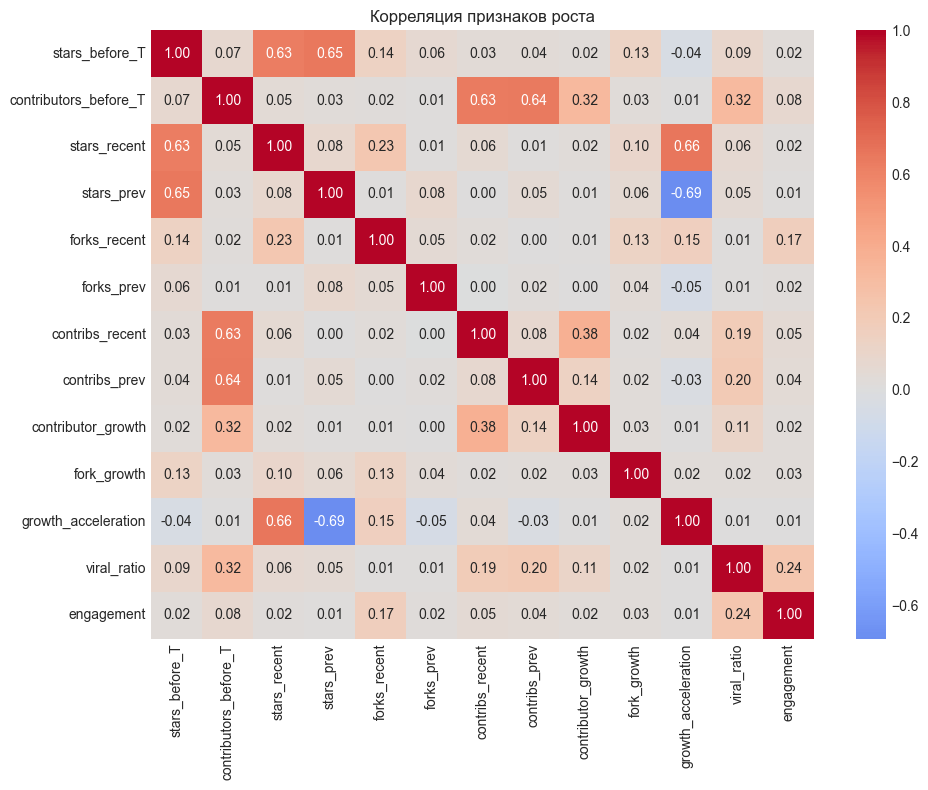


=== Готово для перехода к этапу anomaly detection ===


In [15]:
# ============================================================================
# 7. Вычисляем признаки роста, viral ratio, engagement
#    в соответствии с Business Unit Doc (60-дневные окна)
# ============================================================================

print("\n=== Вычисление признаков роста (60-дневные окна) ===\n")

# Убедимся, что у нас есть events_early (события для early-репозиториев)
if 'events_early' not in globals() or events_early is None:
    raise ValueError("events_early не найден. Сначала выполните фильтрацию early-репозиториев.")

# T – последняя дата в данных
T = events_early['event_date'].max()
print(f"Момент анализа T: {T.date()}")

# Определяем границы 60-дневных окон
recent_start = T - timedelta(days=60)
recent_end = T
prev_start = T - timedelta(days=120)
prev_end = T - timedelta(days=60)

print(f"Последние 60 дней: {recent_start.date()} – {recent_end.date()}")
print(f"Предыдущие 60 дней: {prev_start.date()} – {prev_end.date()}\n")

# --------------------------------------------------------------------------
# 7.1. Вспомогательные функции для суммирования по окнам
# --------------------------------------------------------------------------
def sum_events_60d(df, event_type, start, end):
    """Сумма event_count для заданного типа событий в интервале [start, end)"""
    mask = (df['event_type'] == event_type) & (df['event_date'] >= start) & (df['event_date'] < end)
    return df[mask].groupby('repo_id')['event_count'].sum()

def sum_actors_60d(df, event_types, start, end):
    """Сумма unique_actors для заданных типов событий в интервале [start, end)"""
    mask = (df['event_type'].isin(event_types)) & (df['event_date'] >= start) & (df['event_date'] < end)
    return df[mask].groupby('repo_id')['unique_actors'].sum()

# --------------------------------------------------------------------------
# 7.2. Расчёт сумм за последние 60 дней и предыдущие 60 дней
# --------------------------------------------------------------------------
print("Расчёт сумм за периоды...")

# Звёзды (WatchEvent)
stars_recent = sum_events_60d(events_early, 'WatchEvent', recent_start, recent_end).rename('stars_recent')
stars_prev   = sum_events_60d(events_early, 'WatchEvent', prev_start, prev_end).rename('stars_prev')

# Форки (ForkEvent)
forks_recent = sum_events_60d(events_early, 'ForkEvent', recent_start, recent_end).rename('forks_recent')
forks_prev   = sum_events_60d(events_early, 'ForkEvent', prev_start, prev_end).rename('forks_prev')

# Контрибьюторы (PushEvent + PullRequestEvent) – сумма unique_actors
contribs_recent = sum_actors_60d(events_early, ['PushEvent', 'PullRequestEvent'], recent_start, recent_end).rename('contribs_recent')
contribs_prev   = sum_actors_60d(events_early, ['PushEvent', 'PullRequestEvent'], prev_start, prev_end).rename('contribs_prev')

# Общее количество PR (PullRequestEvent) за всё время до T (нужно для Engagement)
total_pr = events_early[events_early['event_type'] == 'PullRequestEvent'] \
    .groupby('repo_id')['event_count'].sum().rename('prs_total')

# Уникальные наблюдатели (Watchers) – для Viral Ratio
watchers_total = events_early[events_early['event_type'] == 'WatchEvent'] \
    .groupby('repo_id')['unique_actors'].sum().rename('watchers_total')

# Накопленные звёзды до T (можно взять из weekly_ts, но пересчитаем из событий)
# Суммируем все WatchEvent до T
stars_before_T = events_early[events_early['event_type'] == 'WatchEvent'] \
    .groupby('repo_id')['event_count'].sum().rename('stars_before_T')

# Накопленные контрибьюторы до T (уникальные акторы для Push+PR)
contributors_before_T = events_early[events_early['event_type'].isin(['PushEvent', 'PullRequestEvent'])] \
    .groupby('repo_id')['unique_actors'].sum().rename('contributors_before_T')

print(" Суммы рассчитаны")

# --------------------------------------------------------------------------
# 7.3. Сборка всех признаков в один DataFrame
# --------------------------------------------------------------------------
# Берём список всех repo_id из early_repos (или из индексов полученных Series)
all_repo_ids = set(early_repos['repo_id'])
base = pd.DataFrame({'repo_id': list(all_repo_ids)})

# Объединяем все Series
features = base.copy()
for s in [stars_recent, stars_prev, forks_recent, forks_prev,
          contribs_recent, contribs_prev, total_pr, watchers_total,
          stars_before_T, contributors_before_T]:
    features = features.merge(s, on='repo_id', how='left')

features = features.fillna(0)

print(f"Размер features после объединения: {features.shape}")

# --------------------------------------------------------------------------
# 7.4. Вычисление производных признаков (согласно Business Unit Doc)
# --------------------------------------------------------------------------
print("\nВычисление признаков роста...")

# 1. Contributor Growth = New Contributors (last 60 days) / Contributors (previous 60 days)
features['contributor_growth'] = np.where(
    features['contribs_prev'] > 0,
    features['contribs_recent'] / features['contribs_prev'],
    0.0
)

# 2. Fork Growth = New Forks (last 60 days) / Forks (previous 60 days)
features['fork_growth'] = np.where(
    features['forks_prev'] > 0,
    features['forks_recent'] / features['forks_prev'],
    0.0
)

# 3. Growth Acceleration (абсолютное ускорение: прирост звёзд в текущем периоде минус прирост в предыдущем)
features['growth_acceleration'] = features['stars_recent'] - features['stars_prev']

# 4. Viral Ratio = Total Contributors / Total Watchers
features['viral_ratio'] = np.where(
    features['watchers_total'] > 0,
    features['contributors_before_T'] / features['watchers_total'],
    0.0
)

# 5. Engagement Indicator = (Forks recent + PRs total) / Stars before T
features['engagement'] = np.where(
    features['stars_before_T'] > 0,
    (features['forks_recent'] + features['prs_total']) / features['stars_before_T'],
    0.0
)

# Дополнительно: относительный рост звёзд (для анализа)
features['star_growth_ratio'] = np.where(
    features['stars_prev'] > 0,
    features['stars_recent'] / features['stars_prev'],
    0.0
)

# --------------------------------------------------------------------------
# 7.5. Вывод статистики по признакам
# --------------------------------------------------------------------------
print("\n=== Статистика полученных признаков ===")
print(f"{'Признак':<25} {'Среднее':>10} {'Медиана':>10} {'Макс':>10} {'Нулей (%)':>12}")
print("-" * 70)

for col in ['contributor_growth', 'fork_growth', 'growth_acceleration', 'viral_ratio', 'engagement', 'star_growth_ratio']:
    mean_val = features[col].mean()
    med_val = features[col].median()
    max_val = features[col].max()
    zero_pct = (features[col] == 0).mean() * 100
    print(f"{col:<25} {mean_val:10.4f} {med_val:10.4f} {max_val:10.2f} {zero_pct:11.1f}%")

# --------------------------------------------------------------------------
# 7.6. Итоговая таблица признаков (отбираем нужные колонки)
# --------------------------------------------------------------------------
final_cols = [
    'repo_id',
    'stars_before_T',
    'contributors_before_T',
    'stars_recent', 'stars_prev',
    'forks_recent', 'forks_prev',
    'contribs_recent', 'contribs_prev',
    'contributor_growth',
    'fork_growth',
    'growth_acceleration',
    'viral_ratio',
    'engagement'
]
features_final = features[final_cols].copy()

print("\n Признаки роста успешно вычислены.")
print(f"Размер финального набора: {features_final.shape}")
print("\nПервые 5 строк:")
print(features_final.head())

# --------------------------------------------------------------------------
# (Опционально) Корреляционная матрица признаков
# --------------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    corr = features_final.drop('repo_id', axis=1).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Корреляция признаков роста')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Корреляционная матрица не построена: {e}")

print("\n=== Готово для перехода к этапу anomaly detection ===")